In [ ]:
# import libraries
import matplotlib.pyplot as plt
from sc_flow import SCFlow
from sc_flow.dataset.toy_data import get_toy_dataset

# create dataset
adata = get_toy_dataset("moons", noise=0.1).adata

# Config-first construction. Everything method-specific (velocity field,
# probability path, flow solver) lives in the opaque `method.config` block,
# validated by the method itself; the framework stays generic.
cfg = {
    "data": {"datamanager": {}},
    "method": {
        "method_id": "cfm",
        "backend": "torch",
        "config": {
            "velocity_field": {
                "vf_decoder_mlp_kwargs": {"hidden_dims": [32, 32]},
                "time_features_id": "torch-cfm",
                "conditioning_id": "resnet1d",
            },
            "probability_path": {"kind": "linear-dirac"},
            "flow_solver": {"kind": "ode", "scheme": "euler", "num_steps": 100},
        },
    },
    "optim": {"optimizer_cls": "Adam", "lr": 1e-4},
    "trainer": {"device": "mps", "n_train_steps": 100_000, "train_batch_size": 128},
}

# Build from the (validated) config. Use `SCFlow.from_yaml("run.yaml", adata)` for a file.
model = SCFlow.from_config(cfg, adata)

# train (trainer/optim settings come from the config)
model.fit(adata)

plt.plot(model.trainer._training_logs["loss"])

Predicting: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]


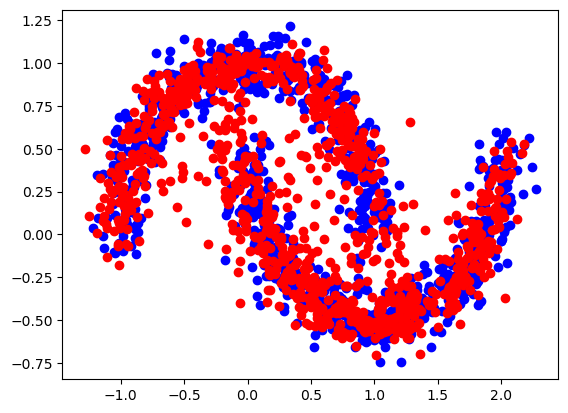

In [6]:
# predict
adata_pred = model.predict(adata)

# visualize
plt.scatter(
    adata.X[:, 0],
    adata.X[:, 1],
    color="blue",
)
plt.scatter(adata_pred.X[:, 0], adata_pred.X[:, 1], color="red")